# Beam-Column Design to SANS 10162-1

**Worked Example E6.1** — Beam-column subject to strong-axis bending

*Reference: Design of Structural Steelwork to SANS 10162, Edition 3 (2013)*


## Setup

Run this cell first. On Google Colab it installs the required libraries and downloads the section property database from GitHub.

In [40]:
import sys, os, subprocess

IN_COLAB = 'google.colab' in sys.modules

required = ['handcalcs', 'forallpeople', 'pandas']
missing = []
for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        missing.append(pkg)

if missing:
    print(f"Installing: {missing}")
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + missing, check=True)

# Fetch section CSVs from GitHub if not present locally
REPO_RAW = "https://raw.githubusercontent.com/SAEng-design/beam-column-notebook/main/data"
for fname in ['h_sections.csv', 'i_sections.csv']:
    if not os.path.exists(fname):
        import urllib.request
        urllib.request.urlretrieve(f"{REPO_RAW}/{fname}", fname)
        print(f"Downloaded {fname}")

print("Setup complete.")


Setup complete.


In [41]:
import handcalcs.render
import forallpeople as si
import pandas as pd
from math import pi, sqrt
from datetime import date
from IPython.display import HTML, display

# Activate forallpeople's structural environment.
# This exposes prefixed unit names (mm, kN, MPa, etc.) in the GLOBAL namespace.
# Use them as bare names — e.g.  2200 * kN  — NOT as si.kN.
si.environment('structural', top_level=True)

print("Libraries loaded. Unit names available globally: mm, m, kN, N, MPa, Pa, kg, etc.")


Libraries loaded. Unit names available globally: mm, m, kN, N, MPa, Pa, kg, etc.


## Project Information

**Edit the dictionary below for each new calculation.** Everything else in the notebook reads from these values.

In [42]:
PROJECT = {
    "project_name":   "Industrial Warehouse Phase 2",
    "project_number": "VIKO-2026-014",
    "location":       "Pretoria, South Africa",
    "client":         "Example Client (Pty) Ltd",
    "member_type":    "Internal Braced Column",
    "member_code":    "COL-B2-12",
    "engineer":       "J. Engineer, Pr.Eng",
    "checked_by":     "S. Senior, Pr.Eng",
    "approved_by":    "M. Director, Pr.Eng",
    "revision":       "Rev A",
    "date":           date.today().isoformat(),
    "calc_ref":       "CALC-E6.1-001",
}



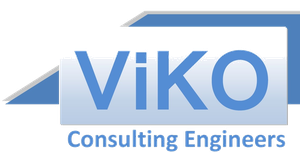

In [43]:
LOGO_B64 = "..."

header_html = f"""
<div style="border:2px solid #4A7BB7; border-radius:6px; padding:14px 18px;
            margin:6px 0 18px 0; font-family: Arial, Helvetica, sans-serif;
            background:linear-gradient(to right,#F4F8FC,#FFFFFF);">
  <table style="width:100%; border-collapse:collapse;">
    <tr>
      <td style="width:280px; vertical-align:middle; padding-right:18px;">
        <img src="data:image/png;base64,{LOGO_B64}"
             style="width:260px; max-width:100%; display:block;" alt="ViKO Consulting Engineers"/>
      </td>
      <td style="vertical-align:middle; border-left:1px solid #B5C9E2; padding-left:18px;">
        <div style="font-size:18px; font-weight:700; color:#2C4A78; margin-bottom:4px;">
          {PROJECT['project_name']}
        </div>
        <div style="font-size:13px; color:#444; margin-bottom:8px;">
          {PROJECT['client']} &nbsp;|&nbsp; {PROJECT['location']}
        </div>
        <table style="font-size:12px; color:#333; border-collapse:collapse;">
          <tr>
            <td style="padding:1px 14px 1px 0;"><b>Project No.:</b> {PROJECT['project_number']}</td>
            <td style="padding:1px 14px 1px 0;"><b>Calc Ref.:</b> {PROJECT['calc_ref']}</td>
            <td style="padding:1px 0;"><b>Revision:</b> {PROJECT['revision']}</td>
          </tr>
          <tr>
            <td style="padding:1px 14px 1px 0;"><b>Member:</b> {PROJECT['member_code']}</td>
            <td style="padding:1px 14px 1px 0;"><b>Type:</b> {PROJECT['member_type']}</td>
            <td style="padding:1px 0;"><b>Date:</b> {PROJECT['date']}</td>
          </tr>
        </table>
      </td>
    </tr>
  </table>
  <table style="width:100%; margin-top:10px; border-top:1px solid #B5C9E2;
                padding-top:8px; font-size:12px; color:#333; border-collapse:collapse;">
    <tr>
      <td style="padding:3px 0;"><b>Engineer:</b> {PROJECT['engineer']}</td>
      <td style="padding:3px 0;"><b>Checked by:</b> {PROJECT['checked_by']}</td>
      <td style="padding:3px 0;"><b>Approved by:</b> {PROJECT['approved_by']}</td>
    </tr>
  </table>
</div>
"""
display(HTML(header_html))


## Section Property Database

Two databases are available — H-sections (UC / heavy columns) in `h_sections.csv` and I-sections (UB / IPE beams) in `i_sections.csv`. Both follow the SAISC Red Book convention. Units: `A` in ×10³ mm², `Ix`/`Iy` in ×10⁶ mm⁴, `Sx`/`Sy` (plastic moduli) in ×10³ mm³, `J` in ×10³ mm⁴, `Cw` in ×10⁹ mm⁶, linear dimensions in mm.

**Set `SECTION_TYPE` to `'H'` or `'I'` to choose which database to load.**

In [44]:
# Choose the section database: 'H' for H-sections, 'I' for I-sections
SECTION_TYPE = 'H'

csv_file = 'h_sections.csv' if SECTION_TYPE == 'H' else 'i_sections.csv'
sections = pd.read_csv(csv_file, sep=';', decimal=',').set_index('designation')
print(f"Loaded {len(sections)} {SECTION_TYPE}-sections from {csv_file}")
sections.head()


Loaded 19 H-sections from h_sections.csv


,m,h,b,tw,tf,r,A,d,Ix,Zex,Sx,rx,Iy,Zey,Sy,ry,J,Cw
designation,,,,,,,,,,,,,,,,,,
152x152x23,23.0,152.4,152.4,6.1,6.8,7.6,2.97,124,12.6,165,184,65.1,4.02,52.7,80.5,36.8,51.5,21.3
152x152x30,30.0,157.5,152.9,6.6,9.4,7.6,3.84,123,17.5,222,248,67.5,5.60,73.3,112.0,38.2,108.0,30.7
152x152x37,37.0,161.8,154.4,8.1,11.5,7.6,4.73,124,22.1,274,309,68.4,7.06,91.5,140.0,38.7,197.0,39.9
203x203x46,46.1,203.2,203.2,7.3,11.0,10.2,5.88,161,45.6,449,497,88.1,15.40,151.0,231.0,51.2,225.0,142.0
203x203x52,52.0,206.2,203.9,8.0,12.5,10.2,6.64,161,52.5,510,567,89.0,17.70,173.0,265.0,51.6,322.0,166.0


In [45]:
# === Trial section selection ===
# To see all available designations, uncomment:
# print(list(sections.index))

SECTION = '305x305x118'
sec = sections.loc[SECTION]
print(f"Selected: {SECTION}")
sec


Selected: 305x305x118


m       118.0
h       314.5
b       306.8
tw       11.9
tf       18.7
r        15.2
A        15.0
d       247.0
Ix      276.0
Zex    1760.0
Sx     1950.0
rx      136.0
Iy       90.1
Zey     587.0
Sy      895.0
ry       77.6
J      1620.0
Cw     1970.0
Name: 305x305x118, dtype: float64

## Design Inputs

Note the unit syntax — `kN`, `MPa`, `mm` are used as bare names (made available globally by the `forallpeople` `structural` environment activated in setup). Do not write `si.kN` — this will fail.

In [46]:
%%render
# Design loads
C_u = 2200 * kN
M_u_top = 180 * kN * m
M_u_bot = 240 * kN * m

# Column geometry
L = 3.2 * m

# Material (Grade S355JR, f_y = 350 MPa per worked example)
STEEL_GRADE = "S355JR"
f_y = 350 * MPa
E   = 200000 * MPa
G   = 77000 * MPa

# Resistance factor
phi = 0.9


<IPython.core.display.Latex object>

In [47]:
%%render
# Section properties — loaded from CSV, converted to SI units
A     = float(sec['A'])  * 1000 * mm**2
I_x   = float(sec['Ix']) * 1e6  * mm**4
I_y   = float(sec['Iy']) * 1e6  * mm**4
J     = float(sec['J'])  * 1000 * mm**4
C_w   = float(sec['Cw']) * 1e9  * mm**6
Z_plx = float(sec['Sx']) * 1000 * mm**3
b_f   = float(sec['b'])  * mm
t_f   = float(sec['tf']) * mm
t_w   = float(sec['tw']) * mm
h_w   = float(sec['d'])  * mm
r_x   = float(sec['rx']) * mm
r_y   = float(sec['ry']) * mm


<IPython.core.display.Latex object>

## Problem Statement

The block below is auto-generated from the design inputs above. If you change a load, length, section, or steel grade, re-run this cell to refresh the statement.

In [48]:
# Auto-generated problem statement from inputs above
def _fmt(qty, unit_str, fmt_spec=",.0f"):
    """Format a forallpeople quantity with the desired unit and number format."""
    # Convert to numeric value in chosen unit by dividing by 1 of that unit
    if unit_str == 'kN':
        val = qty.value / 1000        # SI base = N
    elif unit_str == 'kNm':
        val = qty.value / 1000        # SI base = N·m
    elif unit_str == 'm':
        val = qty.value               # SI base = m
    elif unit_str == 'MPa':
        val = qty.value / 1e6         # SI base = Pa
    else:
        val = qty.value
    return f"{val:{fmt_spec}}"

# Build a description of the load case from the moment ratio
kappa_val = float(M_u_top.value / M_u_bot.value)
curvature = "double curvature" if kappa_val > 0 else "single curvature"
load_case = f"braced column, strong-axis bending, {curvature} (κ = {abs(kappa_val):.2f})"

problem_html = f"""
<div style="border:1px solid #B5C9E2; border-radius:6px; padding:14px 18px;
            margin:8px 0; font-family: Arial, sans-serif; background:#FBFCFE;">
  <div style="font-size:15px; font-weight:700; color:#2C4A78; margin-bottom:10px;">
    Problem Statement
  </div>
  <div style="font-size:13px; color:#333; margin-bottom:10px;">
    Load case: <i>{load_case}</i>
  </div>
  <table style="width:100%; border-collapse:collapse; font-size:13px;">
    <tr style="background:#EEF3FA;">
      <th style="text-align:left; padding:6px 10px; border:1px solid #D6E0EC;">Parameter</th>
      <th style="text-align:left; padding:6px 10px; border:1px solid #D6E0EC;">Symbol</th>
      <th style="text-align:right; padding:6px 10px; border:1px solid #D6E0EC;">Value</th>
    </tr>
    <tr>
      <td style="padding:5px 10px; border:1px solid #D6E0EC;">Axial compressive load</td>
      <td style="padding:5px 10px; border:1px solid #D6E0EC;"><i>C<sub>u</sub></i></td>
      <td style="text-align:right; padding:5px 10px; border:1px solid #D6E0EC;">{_fmt(C_u, 'kN', ',.0f')} kN</td>
    </tr>
    <tr>
      <td style="padding:5px 10px; border:1px solid #D6E0EC;">Bending moment, top (major axis)</td>
      <td style="padding:5px 10px; border:1px solid #D6E0EC;"><i>M<sub>u,top</sub></i></td>
      <td style="text-align:right; padding:5px 10px; border:1px solid #D6E0EC;">{_fmt(M_u_top, 'kNm', ',.0f')} kNm</td>
    </tr>
    <tr>
      <td style="padding:5px 10px; border:1px solid #D6E0EC;">Bending moment, bottom (major axis)</td>
      <td style="padding:5px 10px; border:1px solid #D6E0EC;"><i>M<sub>u,bot</sub></i></td>
      <td style="text-align:right; padding:5px 10px; border:1px solid #D6E0EC;">{_fmt(M_u_bot, 'kNm', ',.0f')} kNm</td>
    </tr>
    <tr>
      <td style="padding:5px 10px; border:1px solid #D6E0EC;">Unbraced length</td>
      <td style="padding:5px 10px; border:1px solid #D6E0EC;"><i>L</i></td>
      <td style="text-align:right; padding:5px 10px; border:1px solid #D6E0EC;">{_fmt(L, 'm', '.2f')} m</td>
    </tr>
    <tr>
      <td style="padding:5px 10px; border:1px solid #D6E0EC;">Trial section</td>
      <td style="padding:5px 10px; border:1px solid #D6E0EC;">—</td>
      <td style="text-align:right; padding:5px 10px; border:1px solid #D6E0EC;">
        {SECTION} {SECTION_TYPE}-section ({sec['m']:.0f} kg/m)
      </td>
    </tr>
    <tr>
      <td style="padding:5px 10px; border:1px solid #D6E0EC;">Steel grade</td>
      <td style="padding:5px 10px; border:1px solid #D6E0EC;"><i>f<sub>y</sub></i></td>
      <td style="text-align:right; padding:5px 10px; border:1px solid #D6E0EC;">
        {STEEL_GRADE} ({_fmt(f_y, 'MPa', '.0f')} MPa)
      </td>
    </tr>
    <tr>
      <td style="padding:5px 10px; border:1px solid #D6E0EC;">Resistance factor</td>
      <td style="padding:5px 10px; border:1px solid #D6E0EC;"><i>φ</i></td>
      <td style="text-align:right; padding:5px 10px; border:1px solid #D6E0EC;">{phi}</td>
    </tr>
  </table>
  <div style="margin-top:10px; font-size:12px; color:#555;">
    <b>Checks required per SANS 10162-1 Clause 13.8.2:</b>
    (i) cross-sectional strength,
    (ii) overall member strength,
    (iii) lateral-torsional buckling.
  </div>
</div>
"""
display(HTML(problem_html))


Parameter,Symbol,Value
Axial compressive load,Cu,"2,200 kN"
"Bending moment, top (major axis)","Mu,top",180 kNm
"Bending moment, bottom (major axis)","Mu,bot",240 kNm
Unbraced length,L,3.20 m
Trial section,—,305x305x118 H-section (118 kg/m)
Steel grade,fy,S355JR (350 MPa)
Resistance factor,φ,0.9


## Cross-Section Classification (Clause 11)

### Compression flange outstand (Clause 11.3.1(c), Table 4)

In [ ]:
%%render
# Flange outstand ratio (dimensionless — units cancel)
flange_ratio = (b_f / 2) / t_f

# Class 1 / Class 2 limits (f_y substituted as numeric MPa value in the formula)
fy_MPa = 350
lambda_Class1_f = 145 / sqrt(fy_MPa)
lambda_Class2_f = 170 / sqrt(fy_MPa)


In [ ]:
import math
fr  = (float(sec['b'])/2)/float(sec['tf'])
c1f = 145/math.sqrt(350)
c2f = 170/math.sqrt(350)
print(f"  Flange b/(2 t_f) = {fr:.2f}")
print(f"  Class 1 limit    = {c1f:.2f}  →  {'within' if fr<=c1f else 'exceeded'}")
print(f"  Class 2 limit    = {c2f:.2f}  →  {'within' if fr<=c2f else 'exceeded'}")
print(f"\n  → Compression flange is Class 2")


### Web in combined axial compression and bending (Clause 11.3.2(c), Table 4)

In [ ]:
%%render
# Web slenderness
web_ratio = h_w / t_w

# Squash load
C_y = A * f_y

# Class 1 limit for web in combined compression and bending
lambda_Class1_w = (1100 / sqrt(fy_MPa)) * (1 - 0.39 * C_u / (phi * C_y))


In [ ]:
wr  = float(sec['d'])/float(sec['tw'])
Cy_num = float(sec['A'])*1e3 * 350
limw = (1100/math.sqrt(350)) * (1 - 0.39 * 2200e3/(0.9*Cy_num))
print(f"  Web h/t_w     = {wr:.2f}")
print(f"  Class 1 limit = {limw:.2f}  →  {'within' if wr<=limw else 'exceeded'}")
print(f"\n  → Web is Class 1")
print(f"  → Overall section classification: CLASS 2")


## Check (i) — Cross-Sectional Strength

**Clause 13.8.2:**
$$\frac{C_u}{C_{rx}} + \frac{0.85\,U_{1x}\,M_{ux}}{M_{rx}} \le 1.0$$

### Compressive resistance $C_{rx}$ — Clause 13.3.1 with $\lambda = 0$

In [ ]:
%%render
# For cross-section check, lambda = 0 → C_rx reduces to phi * A * f_y
C_rx = phi * A * f_y


### Moment resistance $M_{rx}$ — Clause 13.5(a), Class 2 section

In [ ]:
%%render
M_rx = phi * Z_plx * f_y


### Moment amplification factor $U_{1x}$ — Clause 13.8.4

For a braced frame, $\beta = 0.60$. The moment-gradient factor from Clause 13.8.5(a):
$$\omega_{1x} = 0.6 - 0.4\kappa \ge 0.4 \quad ; \quad \kappa = +\frac{M_{u,\text{smaller}}}{M_{u,\text{larger}}} \text{ for double curvature}$$

In [ ]:
%%render
beta = 0.60
kappa = + (M_u_top / M_u_bot)
omega_1x_calc = 0.6 - 0.4 * kappa
omega_1x = max(omega_1x_calc, 0.4)


In [ ]:
%%render
# Euler buckling load about strong axis
KL_x = 1.0 * L
C_ex = (pi**2 * E * I_x) / (KL_x**2)

# Amplification factor (Clause 13.8.4)
U_1x_calc = omega_1x / (1 - C_u / C_ex)

# For cross-section check, U_1x shall not be < 1.0
U_1x = max(U_1x_calc, 1.0)


### Interaction equation

In [ ]:
%%render
M_ux = M_u_bot   # larger end moment governs

ratio_axial_i   = C_u / C_rx
ratio_bending_i = (0.85 * U_1x * M_ux) / M_rx
interaction_i   = ratio_axial_i + ratio_bending_i


In [ ]:
val = float(interaction_i)
verdict = "OK" if val <= 1.0 else "FAIL"
print(f"  Interaction (i)  =  {float(ratio_axial_i):.3f} + {float(ratio_bending_i):.3f}  =  {val:.3f}   <= 1.0   ->   {verdict}")
print(f"  -> Cross-sectional strength is adequate")


## Check (ii) — Overall Member Strength

**Clause 13.8.2** — for uniaxial strong-axis bending in a braced frame, the compressive resistance is based on weak-axis flexural buckling ($C_r = C_{ry}$).

### Weak-axis compressive resistance $C_{ry}$ — Clause 13.3.1

In [ ]:
%%render
K_y = 1.0
slenderness_y = (K_y * L) / r_y
f_ey = (pi**2 * E) / (slenderness_y**2)
lambda_y = sqrt(f_y / f_ey)

# n = 1.34 for hot-rolled H-sections
n_param = 1.34
C_ry = phi * A * f_y * (1 + lambda_y**(2*n_param))**(-1/n_param)


### Interaction equation

For overall member check, the calculated $U_{1x}$ is used (not bounded below by 1.0):

In [ ]:
%%render
U_1x_overall = U_1x_calc   # used as-is, not floored at 1.0

ratio_axial_ii   = C_u / C_ry
ratio_bending_ii = (0.85 * U_1x_overall * M_ux) / M_rx
interaction_ii   = ratio_axial_ii + ratio_bending_ii


In [ ]:
val = float(interaction_ii)
verdict = "OK" if val <= 1.0 else "FAIL"
print(f"  Interaction (ii)  =  {float(ratio_axial_ii):.3f} + {float(ratio_bending_ii):.3f}  =  {val:.3f}   <= 1.0   ->   {verdict}")
print(f"  -> Overall member strength is adequate")


## Check (iii) — Lateral-Torsional Buckling

### Compressive resistance for LTB check — Clause 13.3.2

In [ ]:
%%render
# Flexural buckling stress about weak axis
f_ey_LTB = (pi**2 * E) / ((K_y * L / r_y)**2)

# Polar radius of gyration about the shear centre (doubly-symmetric H: x_0 = y_0 = 0)
r_0_sq = r_x**2 + r_y**2

# Torsional buckling stress (K_z = 1.0 conservative)
K_z = 1.0
KL_z = K_z * L
f_ez = ((pi**2 * E * C_w) / (KL_z**2) + G * J) / (A * r_0_sq)

# Critical elastic stress for LTB
f_e_LTB = min(f_ey_LTB, f_ez)


In [ ]:
%%render
lambda_LTB = sqrt(f_y / f_e_LTB)
C_r_LTB = phi * A * f_y * (1 + lambda_LTB**(2*n_param))**(-1/n_param)


### LTB moment resistance $M_{rx,\text{LTB}}$ — Clause 13.6(a)

For double curvature: $\omega_2 = 1.75 + 1.05\kappa + 0.3\kappa^2 \le 2.5$

In [ ]:
%%render
omega_2_calc = 1.75 + 1.05 * kappa + 0.3 * kappa**2
omega_2 = min(omega_2_calc, 2.5)


In [ ]:
%%render
# Elastic critical moment
KL_LTB = K_y * L
M_cr = (omega_2 * pi / KL_LTB) * sqrt(E * I_y * G * J + (pi * E / L)**2 * I_y * C_w)


In [ ]:
%%render
# Plastic moment (unfactored)
M_px = Z_plx * f_y

# Threshold check
threshold_LTB = 0.67 * M_px


In [ ]:
%%render
# Inelastic LTB — Clause 13.6(a)(i)
M_rx_LTB_calc = 1.15 * phi * M_px * (1 - 0.28 * M_px / M_cr)
M_rx_cap = phi * M_px
M_rx_LTB = M_rx_LTB_calc if M_rx_LTB_calc.value < M_rx_cap.value else M_rx_cap


### Interaction equation for LTB

In [ ]:
%%render
ratio_axial_iii   = C_u / C_r_LTB
ratio_bending_iii = (0.85 * U_1x_overall * M_ux) / M_rx_LTB
interaction_iii   = ratio_axial_iii + ratio_bending_iii


In [ ]:
val = float(interaction_iii)
verdict = "OK" if val <= 1.0 else "FAIL"
print(f"  Interaction (iii)  =  {float(ratio_axial_iii):.3f} + {float(ratio_bending_iii):.3f}  =  {val:.3f}   <= 1.0   ->   {verdict}")
print(f"  -> Lateral-torsional buckling resistance is adequate")


## Summary

In [ ]:
ut_i   = float(interaction_i)
ut_ii  = float(interaction_ii)
ut_iii = float(interaction_iii)

def status_html(v):
    if v <= 1.0:
        return '<td style="text-align:center; padding:5px 10px; border:1px solid #B5C9E2; color:#2E7D32;"><b>OK</b></td>'
    else:
        return '<td style="text-align:center; padding:5px 10px; border:1px solid #B5C9E2; color:#C62828;"><b>FAIL</b></td>'

overall_ok = max(ut_i, ut_ii, ut_iii) <= 1.0

summary_html_str = f"""
<div style="border:2px solid #4A7BB7; border-radius:6px; padding:14px 18px;
            margin-top:18px; font-family: Arial, sans-serif;
            background:#F4F8FC;">
  <div style="font-size:16px; font-weight:700; color:#2C4A78; margin-bottom:8px;">
    Design Summary — Member {PROJECT['member_code']}
  </div>
  <table style="width:100%; border-collapse:collapse; font-size:13px;">
    <tr style="background:#D6E3F3;">
      <th style="text-align:left; padding:6px 10px; border:1px solid #B5C9E2;">Check</th>
      <th style="text-align:left; padding:6px 10px; border:1px solid #B5C9E2;">Clause</th>
      <th style="text-align:right; padding:6px 10px; border:1px solid #B5C9E2;">Utilisation</th>
      <th style="text-align:center; padding:6px 10px; border:1px solid #B5C9E2;">Status</th>
    </tr>
    <tr>
      <td style="padding:5px 10px; border:1px solid #B5C9E2;">(i) Cross-sectional strength</td>
      <td style="padding:5px 10px; border:1px solid #B5C9E2;">13.8.2</td>
      <td style="text-align:right; padding:5px 10px; border:1px solid #B5C9E2;">{ut_i:.2f}</td>
      {status_html(ut_i)}
    </tr>
    <tr>
      <td style="padding:5px 10px; border:1px solid #B5C9E2;">(ii) Overall member strength</td>
      <td style="padding:5px 10px; border:1px solid #B5C9E2;">13.8.2</td>
      <td style="text-align:right; padding:5px 10px; border:1px solid #B5C9E2;">{ut_ii:.2f}</td>
      {status_html(ut_ii)}
    </tr>
    <tr>
      <td style="padding:5px 10px; border:1px solid #B5C9E2;">(iii) Lateral-torsional buckling</td>
      <td style="padding:5px 10px; border:1px solid #B5C9E2;">13.8.2 / 13.6(a)</td>
      <td style="text-align:right; padding:5px 10px; border:1px solid #B5C9E2;">{ut_iii:.2f}</td>
      {status_html(ut_iii)}
    </tr>
  </table>
  <div style="margin-top:12px; padding:10px 14px;
              background:{'#E8F5E9' if overall_ok else '#FFEBEE'};
              border-left:4px solid {'#2E7D32' if overall_ok else '#C62828'};
              font-size:14px; font-weight:600; color:{'#1B5E20' if overall_ok else '#B71C1C'};">
    Section {SECTION} ({sec['m']:.0f} kg/m), Grade S355JR — {'ADEQUATE' if overall_ok else 'NOT ADEQUATE'}
  </div>
  <div style="margin-top:10px; font-size:11px; color:#666;">
    Calculation prepared per SANS 10162-1. Engineer: {PROJECT['engineer']}.
    Checked by: {PROJECT['checked_by']}. Approved by: {PROJECT['approved_by']}.
    Calc Ref. {PROJECT['calc_ref']} ({PROJECT['revision']}), {PROJECT['date']}.
  </div>
</div>
"""
display(HTML(summary_html_str))


## Export the Calculation

### Option A — HTML → Browser print to PDF (recommended)

Run this cell. An HTML file downloads to your computer; open it in your browser and press **Ctrl+P** (or **Cmd+P** on Mac) → **Save as PDF**.

In [ ]:
import subprocess, sys, os, json, glob

IN_COLAB = 'google.colab' in sys.modules

# Get the live notebook from Colab's frontend if possible
nb_path = None
if IN_COLAB:
    try:
        from google.colab import _message
        reply = _message.blocking_request('get_ipynb', timeout_sec=30)
        nb_path = '/content/_current_notebook.ipynb'
        with open(nb_path, 'w') as f:
            json.dump(reply['ipynb'], f)
        print(f"Captured live notebook → {nb_path}")
    except Exception as e:
        print(f"Could not capture live notebook ({e}); searching filesystem...")

if nb_path is None or not os.path.exists(nb_path):
    candidates = []
    for base in ('/content', '.', os.path.expanduser('~')):
        if os.path.isdir(base):
            candidates += glob.glob(os.path.join(base, '*.ipynb'))
    candidates = [c for c in candidates if '.ipynb_checkpoints' not in c]
    if candidates:
        nb_path = max(candidates, key=os.path.getmtime)
        print(f"Found notebook on disk: {nb_path}")

if nb_path is None or not os.path.exists(nb_path):
    raise FileNotFoundError(
        "Could not locate the notebook. Press Ctrl+S in Colab to save, then re-run this cell."
    )

# Build output name from project metadata
out_stem = f"{PROJECT['calc_ref']}_{PROJECT['member_code']}_{PROJECT['revision'].replace(' ','')}"
out_stem = out_stem.replace('/', '-').replace(' ', '_')
out_dir = '/content' if IN_COLAB else '.'

result = subprocess.run(
    [sys.executable, '-m', 'nbconvert',
     '--to', 'html',
     '--output', out_stem,
     '--output-dir', out_dir,
     '--no-input',           # hide code cells; show only rendered handcalcs + outputs
     nb_path],
    capture_output=True, text=True
)

if result.returncode != 0:
    print("STDOUT:", result.stdout)
    print("STDERR:", result.stderr)
    raise RuntimeError(f"nbconvert failed (exit {result.returncode})")

html_path = os.path.join(out_dir, f"{out_stem}.html")
print(f"\nDone: {html_path}")
print()
print("Next:")
print("  1. The HTML will download automatically")
print("  2. Open it in your browser")
print("  3. Ctrl+P (or Cmd+P) -> Save as PDF")

if IN_COLAB:
    from google.colab import files
    files.download(html_path)


---

## Appendix — Notes for the Design Team

### Workflow

1. Open this notebook from the GitHub repo via the **Open in Colab** badge.
2. In Colab: **File → Save a copy in Drive**, then rename per job (e.g. `COL-B2-12_E6_1.ipynb`).
3. Edit the `PROJECT` dictionary in Section 2 with project particulars.
4. Adjust design loads in **Design Inputs** and select your trial section.
5. **Runtime → Run all**.
6. Press **Ctrl+S** to save, then run the **Export** cell to download an HTML copy.
7. Open the HTML in your browser → **Ctrl+P** → **Save as PDF** for the archive.

### A note on units

The `forallpeople` library is activated with `top_level=True`, which puts unit names directly into the global namespace. Write:

```python
C_u = 2200 * kN          # CORRECT
f_y = 350 * MPa          # CORRECT
A   = 15000 * mm**2      # CORRECT
```

Do **not** write `si.kN`, `si.MPa`, etc. — those don't exist as module attributes and will raise `AttributeError`.

### Changing the trial section

Edit the `SECTION` variable. To list available designations:

```python
print(list(sections.index))
```

### Caveats / scope

- This notebook implements **Example E6.1** specifically (uniaxial strong-axis bending, braced frame, double curvature). Other load cases require changes to $\omega_{1x}$, $\omega_2$, and the U-factor logic.
- Material is hard-coded to $f_y = 350~\text{MPa}$ (Grade S355JR per worked example).
- Buckling parameter $n = 1.34$ assumes a hot-rolled H-section. For welded sections, $n = 2.24$.
- $K_z = 1.0$ is conservative for the LTB check.

### References

- SANS 10162-1:2011 — *The structural use of steel — Part 1: Limit-states design of hot-rolled steelwork*
- *Design of Structural Steelwork to SANS 10162*, Edition 3 (2013), SAISC — Example E6.1
- SAISC Red Book — Section property tables
- `handcalcs` — [github.com/connorferster/handcalcs](https://github.com/connorferster/handcalcs)
- `forallpeople` — [github.com/connorferster/forallpeople](https://github.com/connorferster/forallpeople)
